# Experiment No. 7 — Customer Segmentation using K-Means Clustering

| | |
|---|---|
| **Name** | Akshit Negi |
| **Course & Branch** | B.Tech CSE |
| **CUID** | CU24250214 |
| **Subject** | Mastery in Data Analytics and Visualizations and Career Advancement |
| **Sem & Section** | 5th Sem, Section "B" |

---
## Aim
To implement the K-Means Clustering algorithm on a real-world dataset (Mall Customer Segmentation Dataset) and analyze customer groups based on purchasing behavior and demographic characteristics.

## Purpose
Customer segmentation groups customers with similar characteristics so that a business can design targeted marketing campaigns, improve engagement, optimize product recommendations and enhance overall business performance.

## Prerequisites
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, and basic knowledge of unsupervised learning, preprocessing and feature scaling. Runs on Jupyter Notebook or Google Colab.

## Step 1 & 2 — Select the dataset, import libraries and load the data
**Dataset chosen:** *Mall Customer Segmentation Dataset* (200 customers).
Columns: `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`, `Spending Score (1-100)`.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (needed for 3-D plot)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Load from a local file if present (e.g. uploaded to Colab), otherwise download a public copy.
FILE = "Mall_Customers.csv"
URL = "https://raw.githubusercontent.com/kennedykwangari/Mall-Customer-Segmentation-Data/master/Mall_Customers.csv"
df = pd.read_csv(FILE if os.path.exists(FILE) else URL)

print("Shape:", df.shape)
df.head()

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Step 3 — Data preprocessing
* Check / handle **missing values**
* Check / remove **duplicates**
* Select the **relevant features**: `Age`, `Annual Income (k$)`, `Spending Score (1-100)`
  (`CustomerID` is just an identifier and carries no behavioural information; `Gender` is categorical, so it is used later only for profiling the clusters.)

In [ ]:
print("Missing values per column:\n", df.isnull().sum(), "\n")
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().dropna().reset_index(drop=True)   # no-op here, but shown for completeness

features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].copy()
X.head()

Missing values per column:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64 

Duplicate rows: 0


,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


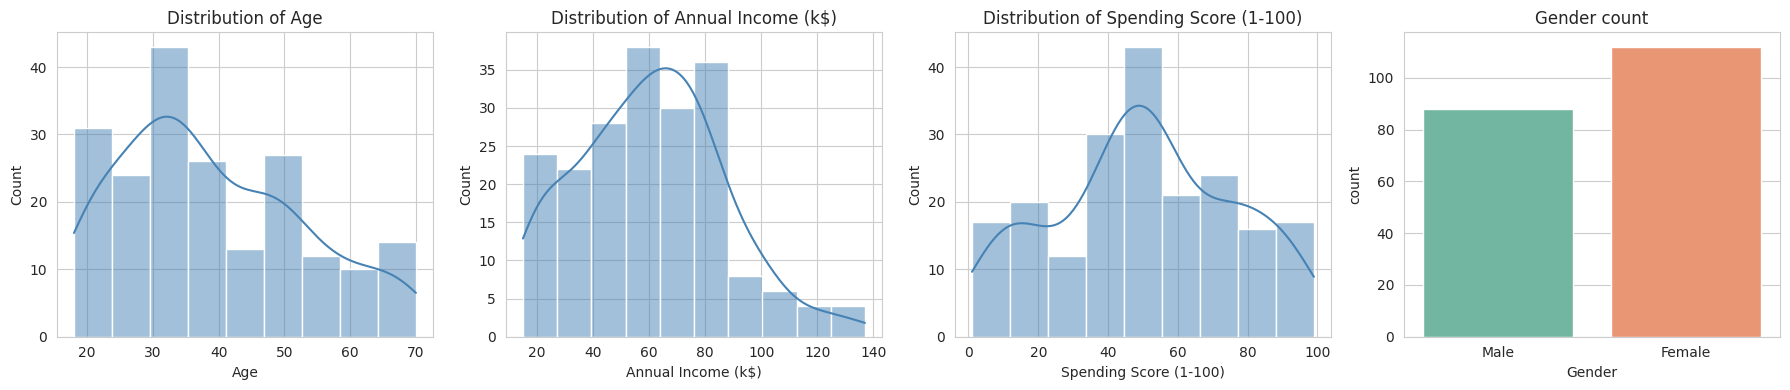

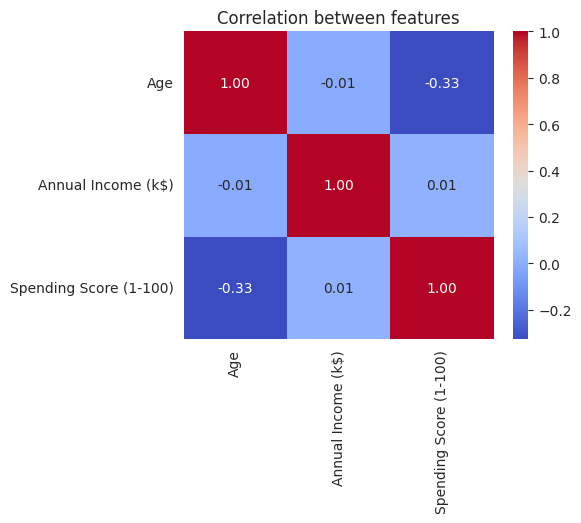

In [ ]:
# Quick exploratory analysis
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes[:3], features):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
sns.countplot(x="Gender", data=df, ax=axes[3], palette="Set2")
axes[3].set_title("Gender count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between features")
plt.show()

**Observation:** The dataset is clean (no missing values, no duplicates). Income and Spending Score are almost uncorrelated, which means they carry independent information — ideal for clustering. Age has a mild negative correlation with Spending Score (younger customers tend to spend more).

## Step 4 — Feature scaling (standardization)
K-Means uses Euclidean distance, so features with large ranges (e.g. income up to 137) would dominate features with small ranges. `StandardScaler` transforms each feature to **mean = 0 and standard deviation = 1** so that all variables contribute equally.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling:")
display(X.describe().loc[["mean", "std", "min", "max"]].round(2))
print("After scaling:")
display(pd.DataFrame(X_scaled, columns=features).describe().loc[["mean", "std", "min", "max"]].round(2))

Before scaling:


,Age,Annual Income (k$),Spending Score (1-100)
mean,38.85,60.56,50.20
std,13.97,26.26,25.82
min,18.00,15.00,1.00
max,70.00,137.00,99.00


After scaling:


,Age,Annual Income (k$),Spending Score (1-100)
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-1.50,-1.74,-1.91
max,2.24,2.92,1.89


## Step 5 — Finding the optimal number of clusters (Elbow Method + Silhouette Score)
* **Elbow Method:** plot the WCSS (inertia) against K and look for the "elbow" where the decrease slows down.
* **Silhouette Score:** measures how well each point fits its own cluster compared to the nearest other cluster (range −1 to +1). The K with the highest average silhouette is preferred.

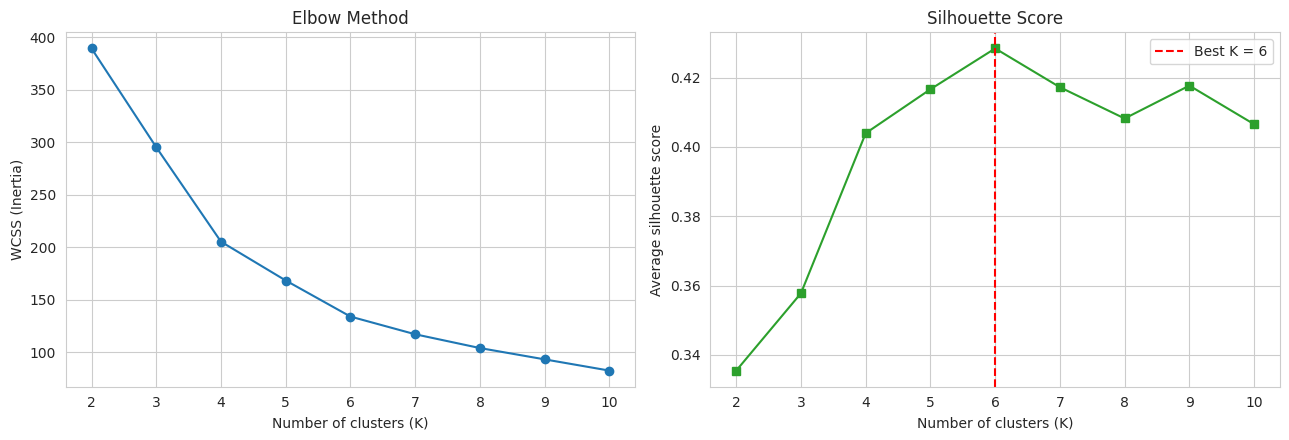

,WCSS,Silhouette
K,,
2,389.39,0.3355
3,295.21,0.3578
4,205.23,0.4040
5,168.25,0.4166
6,133.87,0.4284
7,117.01,0.4172
8,103.87,0.4082
9,93.09,0.4177
10,82.39,0.4066


In [ ]:
K_range = range(2, 11)
wcss, sil = [], []
for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(K_range, wcss, "o-", color="tab:blue")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (K)")
axes[0].set_ylabel("WCSS (Inertia)")

axes[1].plot(K_range, sil, "s-", color="tab:green")
best_k = list(K_range)[int(np.argmax(sil))]
axes[1].axvline(best_k, ls="--", color="red", label=f"Best K = {best_k}")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("Average silhouette score")
axes[1].legend()
plt.tight_layout()
plt.show()

pd.DataFrame({"K": list(K_range), "WCSS": np.round(wcss, 2), "Silhouette": np.round(sil, 4)}).set_index("K")

**Observation:** The WCSS curve bends noticeably around **K = 5–6** and flattens afterwards, and the Silhouette Score is highest at **K = 6** (≈ 0.43). Both methods agree, so **K = 6** is chosen.

## Step 6 — Apply K-Means with the selected K

In [ ]:
K = best_k
kmeans = KMeans(n_clusters=K, init="k-means++", n_init=10, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print(f"K = {K}")
print(f"Inertia (WCSS)   : {kmeans.inertia_:.2f}")
print(f"Silhouette score : {silhouette_score(X_scaled, df['Cluster']):.4f}\n")
print("Customers per cluster:")
print(df["Cluster"].value_counts().sort_index())

K = 6
Inertia (WCSS)   : 133.87
Silhouette score : 0.4284

Customers per cluster:
Cluster
0    45
1    39
2    33
3    39
4    23
5    21
Name: count, dtype: int64


## Step 7 — Visualizing the clusters and centroids
Centroids are computed in scaled space, so we convert them back to the original units with `scaler.inverse_transform` before plotting.

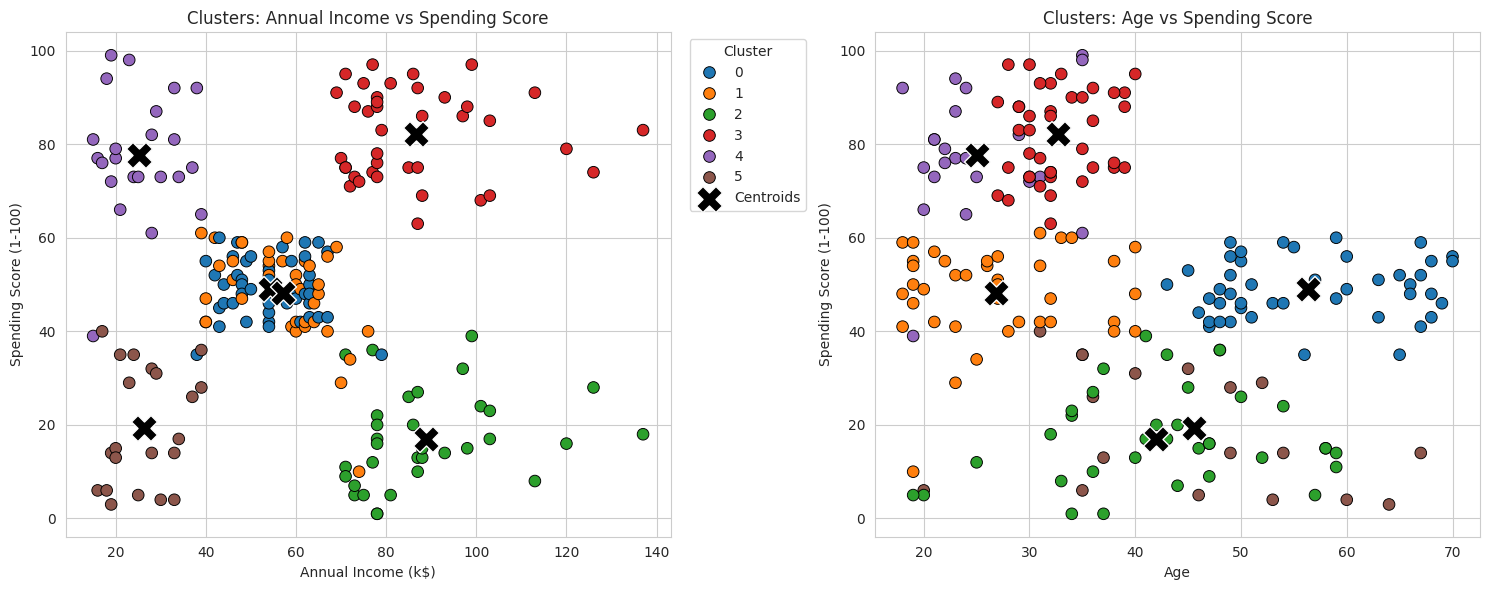

In [ ]:
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features)
palette = sns.color_palette("tab10", K)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Income vs Spending Score
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
                hue="Cluster", palette=palette, s=70, edgecolor="k", ax=axes[0])
axes[0].scatter(centroids["Annual Income (k$)"], centroids["Spending Score (1-100)"],
                c="black", marker="X", s=350, label="Centroids", edgecolor="white")
axes[0].set_title("Clusters: Annual Income vs Spending Score")
axes[0].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")

# Age vs Spending Score
sns.scatterplot(data=df, x="Age", y="Spending Score (1-100)",
                hue="Cluster", palette=palette, s=70, edgecolor="k", ax=axes[1], legend=False)
axes[1].scatter(centroids["Age"], centroids["Spending Score (1-100)"],
                c="black", marker="X", s=350, edgecolor="white")
axes[1].set_title("Clusters: Age vs Spending Score")
plt.tight_layout()
plt.show()

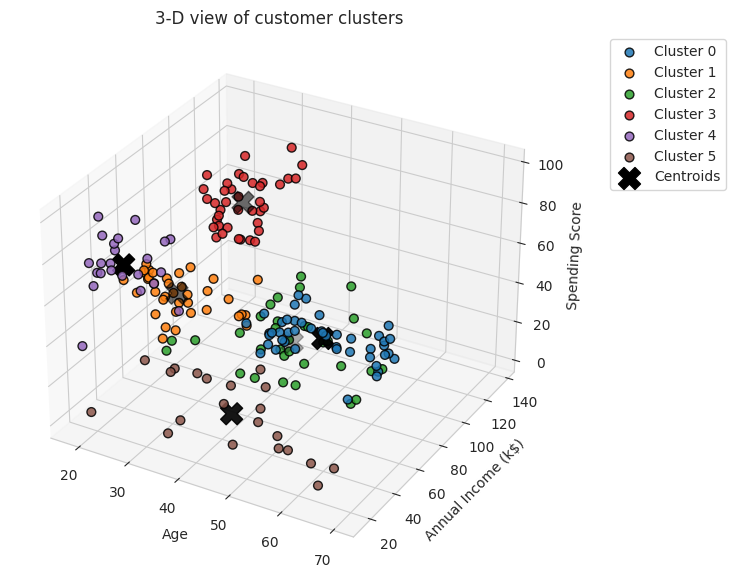

In [ ]:
# 3-D view of all three clustering features
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
for c in range(K):
    sub = df[df["Cluster"] == c]
    ax.scatter(sub["Age"], sub["Annual Income (k$)"], sub["Spending Score (1-100)"],
               s=40, color=palette[c], label=f"Cluster {c}", edgecolor="k", alpha=0.85)
ax.scatter(centroids["Age"], centroids["Annual Income (k$)"], centroids["Spending Score (1-100)"],
           c="black", marker="X", s=250, label="Centroids")
ax.set_xlabel("Age"); ax.set_ylabel("Annual Income (k$)"); ax.set_zlabel("Spending Score")
ax.set_title("3-D view of customer clusters")
ax.legend(bbox_to_anchor=(1.1, 1), loc="upper left")
plt.show()

**Observation:** In the Income-vs-Spending view, four clusters are clearly separated (high/low income × high/low spending). The two mid-income, mid-spending clusters (0 and 1) overlap there because they are separated mainly by **age** (see the Age-vs-Spending plot and the 3-D plot) — this is why Age was included as a clustering feature.

## Step 8 — Analyzing the characteristics of each segment

In [ ]:
profile = df.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Age=("Age", "mean"),
    Avg_Income_k=("Annual Income (k$)", "mean"),
    Avg_Spending=("Spending Score (1-100)", "mean"),
    Pct_Female=("Gender", lambda s: (s == "Female").mean() * 100),
).round(1)

# Give each cluster a business-friendly name using simple rules on its centroid
def name_segment(r):
    inc, spd, age = r["Avg_Income_k"], r["Avg_Spending"], r["Avg_Age"]
    if inc >= 70 and spd >= 60: return "Premium Spenders"
    if inc >= 70 and spd < 40:  return "Affluent Savers"
    if inc < 40 and spd >= 60:  return "Young Trendy Spenders"
    if inc < 40 and spd < 40:   return "Budget-Conscious"
    return "Mature Moderates" if age >= 40 else "Young Average Shoppers"

profile["Segment"] = profile.apply(name_segment, axis=1)
df["Segment"] = df["Cluster"].map(profile["Segment"])
profile

,Customers,Avg_Age,Avg_Income_k,Avg_Spending,Pct_Female,Segment
Cluster,,,,,,
0,45,56.3,54.3,49.1,57.8,Mature Moderates
1,39,26.8,57.1,48.1,64.1,Young Average Shoppers
2,33,41.9,88.9,17.0,42.4,Affluent Savers
3,39,32.7,86.5,82.1,53.8,Premium Spenders
4,23,25.0,25.3,77.6,56.5,Young Trendy Spenders
5,21,45.5,26.3,19.4,61.9,Budget-Conscious


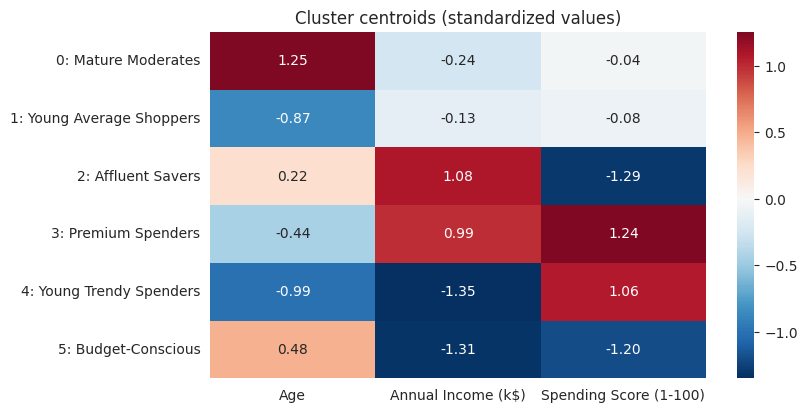

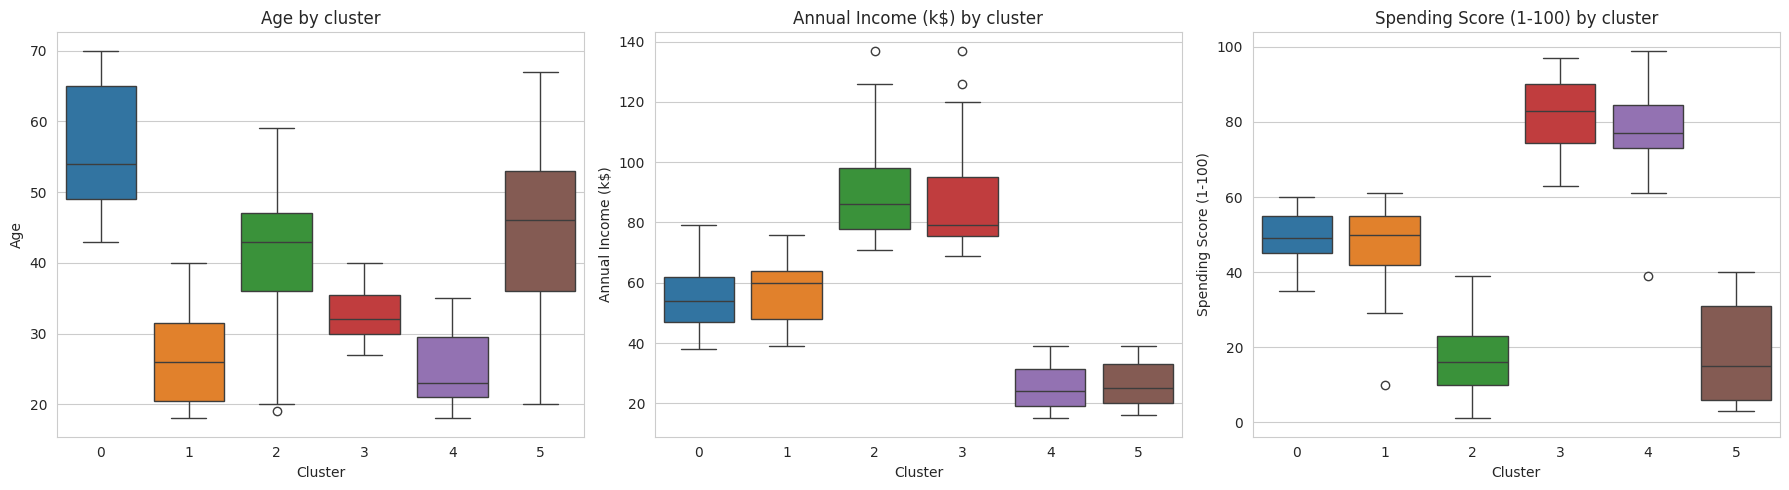

In [ ]:
# Heat-map of standardized centroids: red = above average, blue = below average
z = pd.DataFrame(kmeans.cluster_centers_, columns=features)
z.index = [f"{c}: {profile.loc[c, 'Segment']}" for c in z.index]
plt.figure(figsize=(8, 4.5))
sns.heatmap(z, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Cluster centroids (standardized values)")
plt.show()

# Box plots per segment
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, features):
    sns.boxplot(data=df, x="Cluster", y=col, palette=palette, ax=ax)
    ax.set_title(f"{col} by cluster")
plt.tight_layout()
plt.show()

### Interpretation of the segments
| Segment | Typical profile | Meaning for the business |
|---|---|---|
| **Premium Spenders** | Age ≈ 33, income ≈ 87k, spending ≈ 82 | Wealthy **and** spend freely — the most valuable customers |
| **Affluent Savers** | Age ≈ 42, income ≈ 89k, spending ≈ 17 | High purchasing power but rarely buy — untapped potential |
| **Young Trendy Spenders** | Age ≈ 25, income ≈ 25k, spending ≈ 78 | Low income but enthusiastic, trend-driven shoppers |
| **Budget-Conscious** | Age ≈ 46, income ≈ 26k, spending ≈ 19 | Low income and low spending — very price sensitive |
| **Mature Moderates** | Age ≈ 56, income ≈ 54k, spending ≈ 49 | Mid income, average spending, older customers |
| **Young Average Shoppers** | Age ≈ 27, income ≈ 57k, spending ≈ 48 | Mid income, average spending, young adults |

## Step 9 — Comparison of the customer groups and suggested marketing strategies

In [ ]:
strategies = {
    "Premium Spenders": "VIP / loyalty programme, early access to new collections, personalised premium offers, exclusive events.",
    "Affluent Savers": "Re-engagement campaigns, luxury & high-quality product showcases, personalised recommendations, limited-time exclusive offers to trigger purchases.",
    "Young Trendy Spenders": "Social-media & influencer campaigns, trendy/fashion products, EMI / buy-now-pay-later, student & festival discounts, referral rewards.",
    "Budget-Conscious": "Discounts, combo packs, value-for-money and clearance sales, coupons and cash-back to increase basket size.",
    "Mature Moderates": "Convenience & service-oriented marketing, quality/comfort products, loyalty points, email & SMS offers, retention focus.",
    "Young Average Shoppers": "Upsell & cross-sell bundles, app-based reward points, seasonal promotions to move them up to higher spending.",
}
summary = profile[["Segment", "Customers", "Avg_Age", "Avg_Income_k", "Avg_Spending"]].copy()
summary["Suggested marketing strategy"] = summary["Segment"].map(strategies)
pd.set_option("display.max_colwidth", None)
summary.sort_values("Avg_Spending", ascending=False).reset_index(drop=True)

,Segment,Customers,Avg_Age,Avg_Income_k,Avg_Spending,Suggested marketing strategy
0,Premium Spenders,39,32.7,86.5,82.1,"VIP / loyalty programme, early access to new collections, personalised premium offers, exclusive events."
1,Young Trendy Spenders,23,25.0,25.3,77.6,"Social-media & influencer campaigns, trendy/fashion products, EMI / buy-now-pay-later, student & festival discounts, referral rewards."
2,Mature Moderates,45,56.3,54.3,49.1,"Convenience & service-oriented marketing, quality/comfort products, loyalty points, email & SMS offers, retention focus."
3,Young Average Shoppers,39,26.8,57.1,48.1,"Upsell & cross-sell bundles, app-based reward points, seasonal promotions to move them up to higher spending."
4,Budget-Conscious,21,45.5,26.3,19.4,"Discounts, combo packs, value-for-money and clearance sales, coupons and cash-back to increase basket size."
5,Affluent Savers,33,41.9,88.9,17.0,"Re-engagement campaigns, luxury & high-quality product showcases, personalised recommendations, limited-time exclusive offers to trigger purchases."


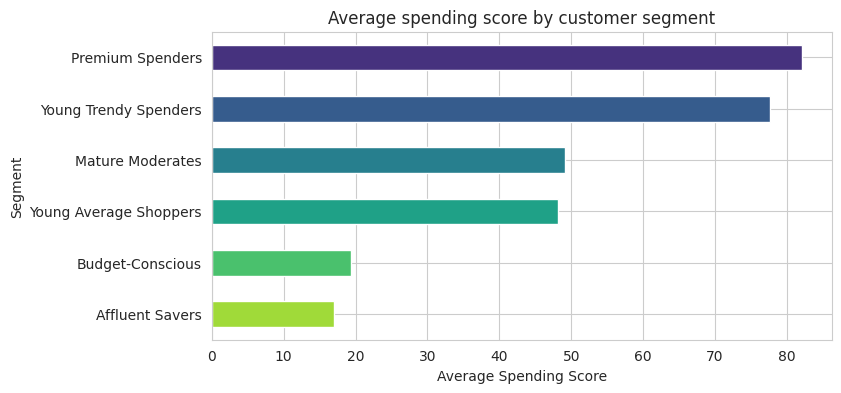

,Customers,Avg_Spending,% of customers
Segment,,,
Premium Spenders,39,82.128205,19.5
Young Trendy Spenders,23,77.608696,11.5
Mature Moderates,45,49.066667,22.5
Young Average Shoppers,39,48.128205,19.5
Budget-Conscious,21,19.380952,10.5
Affluent Savers,33,16.969697,16.5


In [ ]:
# Which segments contribute most (share of customers vs. share of "spending power")
share = df.groupby("Segment").agg(Customers=("CustomerID", "count"), Avg_Spending=("Spending Score (1-100)", "mean"))
share["% of customers"] = (share["Customers"] / len(df) * 100).round(1)
share = share.sort_values("Avg_Spending", ascending=False)

ax = share["Avg_Spending"].plot(kind="barh", figsize=(8, 4), color=sns.color_palette("viridis", len(share)))
ax.invert_yaxis()
ax.set_xlabel("Average Spending Score")
ax.set_title("Average spending score by customer segment")
plt.show()
share

## Step 10 — Summary of results and business value
* The Mall Customer dataset (200 records, 3 features) was cleaned, standardized and clustered with K-Means.
* The **Elbow Method** and **Silhouette Score** both supported **K = 6** (silhouette ≈ 0.43, i.e. reasonably well-separated clusters).
* Six meaningful segments were found: **Premium Spenders, Affluent Savers, Young Trendy Spenders, Budget-Conscious, Mature Moderates and Young Average Shoppers.**
* Each segment differs clearly in income, spending behaviour and age, so a **different marketing strategy** was proposed for each.
* **Business impact:** Segmentation lets a business spend its marketing budget where it matters — retain and reward high-value customers, convert high-income low-spenders, nurture young enthusiastic buyers, and offer value deals to price-sensitive customers — leading to higher conversion, better retention and improved return on marketing investment.

**Conclusion:** K-Means clustering was successfully implemented for customer segmentation, and the resulting groups provide actionable insights for targeted marketing and better business decision-making.

---
# Answers to Questions

### Q1. What is clustering? How does it differ from classification?
**Clustering** is an unsupervised learning technique that groups a set of data points into clusters so that points in the same cluster are highly similar to each other and dissimilar to points in other clusters. There are **no predefined labels** — the groups are discovered from the data itself (e.g. grouping customers by behaviour).

**Classification** is a supervised learning technique that assigns new data to **predefined classes** using a model trained on labelled data (e.g. spam / not spam).

| Basis | Clustering | Classification |
|---|---|---|
| Learning type | Unsupervised | Supervised |
| Labels | Not required | Required (labelled training data) |
| Goal | Discover natural groups / structure | Predict a known class label |
| Number of groups | Unknown / chosen by the user (K) | Fixed, defined beforehand |
| Evaluation | Silhouette score, WCSS, Davies-Bouldin | Accuracy, precision, recall, F1 |
| Examples | Customer segmentation, document grouping | Spam detection, disease diagnosis |

### Q2. Explain the working principle of the K-Means Clustering algorithm.
K-Means partitions *n* data points into *K* clusters by repeatedly moving cluster centres (centroids) so that the total within-cluster distance is minimized.

**Steps**
1. **Choose K**, the number of clusters.
2. **Initialize** K centroids (randomly, or with *k-means++* for better starting points).
3. **Assignment step:** assign every data point to its **nearest centroid** using Euclidean distance
   $d(x, \mu_j) = \sqrt{\sum_{i=1}^{m}(x_i - \mu_{ji})^2}$
4. **Update step:** recompute each centroid as the **mean** of all points assigned to it
   $\mu_j = \frac{1}{|C_j|}\sum_{x \in C_j} x$
5. **Repeat** steps 3–4 until the centroids stop changing (convergence) or the maximum number of iterations is reached.

**Objective function (minimized):**
$J = \sum_{j=1}^{K}\sum_{x \in C_j} \lVert x - \mu_j \rVert^2$ (this is the WCSS / inertia).

K-Means always converges, but possibly to a **local minimum**, so it is run several times with different initializations (`n_init`) and the best result is kept.

### Q3. Why is feature scaling important before applying K-Means clustering?
K-Means is **distance-based** (Euclidean distance). If features are on different scales — e.g. *Annual Income* (15–137) vs. *Age* (18–70) or *Spending Score* (1–100) — the feature with the larger range dominates the distance calculation and therefore dominates the clusters, while smaller-scale features are practically ignored.

Scaling (standardization: $z = (x-\mu)/\sigma$, or Min-Max normalization) puts all features on a comparable scale so that:
* every feature contributes **equally** to the distance,
* the resulting clusters are not biased by units of measurement,
* the algorithm converges faster and gives more meaningful, stable clusters.

### Q4. What is the Elbow Method, and how does it help determine the optimal number of clusters?
The **Elbow Method** is a graphical technique for choosing K.
1. Run K-Means for a range of K values (e.g. 1–10).
2. For each K compute the **WCSS** (Within-Cluster Sum of Squares / inertia) — the sum of squared distances of points to their cluster centroid.
3. Plot WCSS (y-axis) against K (x-axis).

As K increases, WCSS always decreases (with K = n it becomes 0). At first the drop is steep because new clusters capture real structure; after a certain K the curve **flattens**. The point where the curve bends like an **elbow** marks the best trade-off: adding more clusters beyond it gives only marginal improvement while making the model more complex. That K is taken as the optimal number of clusters (here K ≈ 5–6).

*Limitation:* the elbow is sometimes ambiguous, so it is validated with the Silhouette Score.

### Q5. What is the Silhouette Score? How is it used to evaluate clustering performance?
The **Silhouette Score** measures how well each data point lies within its cluster compared with other clusters.

For a point *i*:
* $a(i)$ = average distance to all other points in the **same** cluster (cohesion)
* $b(i)$ = average distance to the points in the **nearest other** cluster (separation)

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}}, \qquad -1 \le s(i) \le 1$$

**Interpretation**
* **Close to +1:** point is well matched to its own cluster and far from neighbouring clusters (good clustering)
* **Around 0:** point lies on the boundary between two clusters (overlapping clusters)
* **Negative:** point is probably assigned to the wrong cluster

The **average silhouette score** of all points is computed for different values of K, and the K with the **highest** score is chosen. In this experiment K = 6 gave the highest score (≈ 0.43). Unlike WCSS, it needs no ground-truth labels and gives a clear maximum, which makes it a good complement to the Elbow Method.

### Q6. Why is K-Means considered an unsupervised machine learning algorithm?
K-Means is unsupervised because:
* it works on **unlabelled data** — there is no target/output variable (`y`), only input features (`X`);
* it is not told the "right answers" during training; instead it **discovers hidden structure/patterns** (groups) purely from similarity between data points;
* the cluster labels (0, 1, 2 …) it produces are just group identifiers created by the algorithm, not predefined classes;
* there is no training/testing against ground truth — performance is judged with internal measures such as WCSS and Silhouette Score.

### Q7. Mention any four real-world applications of customer segmentation.
1. **Targeted marketing & advertising** – sending personalised offers, e-mails and ads to each segment (e-commerce, retail).
2. **Product recommendation & personalization** – recommending products/movies/music to groups with similar tastes (Amazon, Netflix, Spotify).
3. **Customer retention & churn prediction** – identifying at-risk or high-value customers in banking, telecom and subscription services and designing loyalty programmes.
4. **Pricing & promotion strategy** – deciding discounts, premium plans or credit/insurance offers per segment (banking, insurance, airlines, hotels).

*(Other examples: store layout and inventory planning in supermarkets, credit-risk profiling, new-product development.)*

### Q8. What are the limitations of the K-Means algorithm?
* **K must be specified in advance** — the user has to guess/estimate the number of clusters.
* **Sensitive to initial centroids** — poor initialization can lead to a local minimum (mitigated with k-means++ and multiple runs).
* **Sensitive to outliers and noise** — because centroids are means, extreme values pull them away from the true centre.
* **Assumes spherical, equally sized clusters** — performs poorly on elongated, non-convex or differently sized/dense clusters.
* **Affected by feature scale** — needs feature scaling.
* **Works only with numeric data** — categorical variables need encoding or K-Modes/K-Prototypes.
* **Hard assignment** — each point belongs to exactly one cluster (no probabilities, unlike Gaussian Mixture Models).
* **Suffers in high dimensions** — distances become less meaningful (curse of dimensionality).

### Q9. How can businesses use customer segmentation to improve marketing and customer retention?
* **Personalized campaigns:** tailor messages, offers and channels to each segment, which raises response and conversion rates.
* **Efficient budget allocation:** spend more on high-value segments (e.g. Premium Spenders) and use low-cost automated campaigns for low-value ones.
* **Loyalty & reward programmes:** VIP benefits, points and early access for best customers to keep them loyal.
* **Win-back and re-engagement:** identify low-activity or high-income/low-spending customers (Affluent Savers) and target them with special offers or reminders.
* **Churn prevention:** monitor segments showing declining activity and act early with incentives or better service.
* **Product & pricing decisions:** develop products and set prices that match the needs and willingness to pay of each group.
* **Cross-selling / up-selling:** recommend relevant add-ons and upgrades to move customers to higher-value segments.
* **Better customer experience:** improved satisfaction → higher retention and customer lifetime value (CLV).

### Q10. Compare K-Means Clustering with Hierarchical Clustering based on their working principles and applications.
**K-Means (partitional):** partitions data into a fixed number K of non-overlapping clusters by iteratively assigning points to the nearest centroid and updating centroids.

**Hierarchical (agglomerative / divisive):** builds a **tree of clusters (dendrogram)**. Agglomerative clustering starts with every point as its own cluster and repeatedly merges the two closest clusters (using single, complete, average or Ward linkage) until one cluster remains; divisive does the reverse. The dendrogram is cut at a chosen height to get the clusters.

| Basis | K-Means | Hierarchical Clustering |
|---|---|---|
| Approach | Partitional, centroid-based | Tree-based (bottom-up / top-down) |
| Number of clusters | Must be specified **before** running | Not needed in advance; chosen afterwards by cutting the dendrogram |
| Output | Flat set of K clusters + centroids | Dendrogram showing nested cluster relationships |
| Time complexity | Approximately O(n·K·i·d) — fast and scalable | O(n²) memory / O(n²–n³) time — slow for large data |
| Dataset size | Suitable for large datasets | Suitable for small–medium datasets |
| Cluster shape | Tends to find spherical clusters | Can handle more varied shapes (depends on linkage) |
| Reproducibility | Depends on random initialization | Deterministic (same result every run) |
| Reversibility | Points can move between clusters in later iterations | Once merged/split, a decision cannot be undone |
| Outlier sensitivity | High | Moderate–high (depends on linkage) |
| Typical applications | Customer segmentation, image compression / colour quantization, document clustering on large data | Gene-expression / phylogenetic trees, taxonomy of species, social-network analysis, small datasets where the hierarchy itself is informative |